# Death-time calibration

How to choose the movement threshold, and a band around it to check by eye, so that each mite's **death** is put where the labels put it. A mite dies at the recording after its last movement (`classes/survival.py`), so in a long run a single still recording called moving, hours after the death, moves the death there.

The notebook has two parts:

1. **The long run** (`test_run_2026-09-08_Mathis_last_dsRNA`, 295 recordings), with the setup in `config.yaml`: how much the mites differ, whether normalising their scores helps, which threshold puts the deaths right, and what a band checked by eye adds.
2. **Every labelled dataset, split into train and test mites**: the Optuna search of the metric, its parameters, the normalisations, the threshold and the band, by the death-time error. The search is run by `scripts/optuna_death_time.py`; this notebook reads its studies.

**To reproduce:** run the search (about 1.5 hours, most of it `optical_flow`; the same `--study` name carries on where it stopped), then run this notebook from top to bottom.

```
python scripts/optuna_death_time.py --study death_time
```

The first run of either cuts every mite's patch out of every frame and keeps them in the system's temporary folder (about 5 GB), so later runs start at once. Everything is scored on this computer, as the app scores it; the logic is in `classes/death_calibration.py`.

## Findings (run of 7 October 2026)

These are the numbers of the run saved in this notebook; running it again on other data changes them. Death errors are in recordings.

**The long run (59 mites, 295 recordings, setup in use: `topN_variability`, n = 759, threshold 3.476)**

- **The mites' floors differ, but that is not what goes wrong.** The floors run from 1.25 to 2.08 and follow the patch brightness (r = 0.98), yet the threshold sits at least 11 of a still mite's noises above every floor. What differs is how hard the mites move: the median moving score per mite runs from 3.6 to 11.1 and has nothing to do with the floor (r = -0.23).
- **Normalising does not help.** AUC is 0.997 with nothing, 0.995 to 0.996 with brightness, the floor or both, and the best death error is 3.4 to 3.9 with any of them.
- **The threshold by recording is the wrong one for a long run.** Sensitivity + specificity suggests 2.26, which calls 1.2% of the still recordings moving: a death error of 12.7, with 17 deaths more than 3 recordings late. The threshold in use gives 5.6; the smallest error, 3.5, is at about 4.2, where no death is late and 10 are early.
- **That holds on mites it was not chosen on.** Picked on half the mites it is 3.95 in the middle (8 in 10 between 3.75 and 4.20), and gives 4.5 on the other half against 5.6 at the threshold in use, better in 85% of 500 splits.
- **It depends on the length of the run.** From 30 recordings on, 4.0 to 4.25 is at or near the best; a run of 12 recordings prefers about 2.9.
- **Asking for a second movement nearby makes it worse**: the real movements near a death are alone too.
- **A band checked by eye does better than any threshold.** With 2.5 to 4.24, 52 of 59 deaths are exact (37 at the threshold in use) for 43 checks in the whole run, at most 4 for one mite. Below 2.5 the band runs into the still scores and the checks multiply. 7 mites have a last movement scoring below 2.5: no band reaches those.

**Every dataset, 74 train and 74 test mites**

- **No metric is clearly better than the one in use.** `topN_temporal_range` (n = 21, threshold 18.85) and `topN_vector_temporal_range` (n = 6, threshold 107) are best on the train mites (1.22) and give 2.65 and 2.62 on the test mites; the searched `topN_variability` (n = 512, threshold 3.655, brightness) gives 2.80, and the setup in use 3.15. Over 50 other splits those are 2.1 to 2.3, each with a spread of 0.65 to 0.90: the differences are within the luck of the split.
- **`optical_flow` and `topN_binary_flux` are behind**: 3.99 and 18.58 on the test mites after 300 and 150 trials.
- **Nearly all the error is the long run's**: 5.8 to 7.6 on its test mites for the metrics above, at most 0.3 on the three short datasets.
- **The band matters more than the metric.** For the setup in use, the band chosen on the train mites (2.69 to 3.94) brings the test error from 3.15 to 1.62 with 0.3 checks per mite, 92% of the deaths exact. For `topN_temporal_range` the band brings it from 2.65 to 2.09 at best.

**What to keep in mind**

- The labels stand in for the eye, so the band's numbers are the best a check can do.
- The long run has 10 frames per recording and the short datasets 30; one threshold is used for both.
- Scores made on another computer differ a little: the long run's scores saved with the dataset differ from this computer's by up to about 0.12, as much as a still mite's noise.

In [1]:
import os
import sys
import tempfile
from concurrent.futures import ProcessPoolExecutor
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path[:0] = [str(ROOT), str(ROOT / "scripts")]

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from IPython.display import display

import pipeline
from classes import calibration, death_calibration
from classes.analyzer import Analyzer
from classes.app_config import get_default_config
from classes.death_calibration import LabelledRun
from optuna_death_time import (STORAGE, _init_worker, bands, in_use, load_dataset, normalised, resplit, runs_of,
                               score_all, split_mites)

# The project's reporting module switches matplotlib to Agg (no figures) on import.
%matplotlib inline

STUDY = "death_time"   # the --study name given to scripts/optuna_death_time.py
SEED, TEST_SHARE = 0, 0.5  # as given to it (its defaults)
RESPLITS = 50          # other splits the threshold is chosen and judged on
CHECKS = [0.25, 0.5, 1, 2]  # checks by eye allowed per mite, one band for each
JOBS = os.cpu_count()
CACHE = Path(tempfile.gettempdir()) / "varroa_death_time_patches"

# Chart style, as in metric_calibration.ipynb: thin marks, recessive axes and grid, text in ink colours.
BLUE, ORANGE, AQUA, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#8d8c85"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3dc"
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelsize": 9.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "legend.frameon": False, "legend.fontsize": 8.5, "lines.linewidth": 2,
})
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option("display.precision", 3)

## The labelled datasets

Every dataset saved in `calibration_data/`, the detections marked *not a mite* left out. The scores below are those of the setup in `config.yaml`.

In [2]:
mite_config = get_default_config().mite
STABILIZE = mite_config.stabilize_plate
IN_USE = (mite_config.metric, mite_config.params_for(mite_config.metric))
THRESHOLD = float(mite_config.motion_threshold)

CACHE.mkdir(parents=True, exist_ok=True)
datasets = [load_dataset(summary, CACHE, STABILIZE, JOBS) for summary in pipeline.list_calibration_datasets()]
datasets = sorted((d for d in datasets if d), key=lambda d: d["name"])
pool = ProcessPoolExecutor(JOBS, initializer=_init_worker, initargs=([(d["path"], d["sizes"]) for d in datasets],))

in_use_scored = score_all(pool, datasets, *IN_USE)  # per dataset: (scores, brightness), each (mites, recordings)
print(f"\nIn use: {IN_USE[0]} {IN_USE[1]}, threshold {THRESHOLD:g}, stabilize_plate {STABILIZE}, "
      f"normalised by brightness {mite_config.normalize_brightness}, by floor {mite_config.normalize_floor}")
display(pd.DataFrame([{"dataset": d["name"], "mites": len(d["mites"]), "recordings": d["moving"].shape[1],
                       "moving labels": int(d["moving"].sum()),
                       "still labels": int((d["labelled"] & ~d["moving"]).sum())} for d in datasets]))

  test_run_2026-09-08_Mathis_last_dsRNA: 59 mites, 295 recordings
  ground_truth_60min: 32 mites, 6 recordings
  sample_data: 29 mites, 6 recordings
  ground_truth_90min: 28 mites, 6 recordings



In use: topN_variability {'n': 759}, threshold 3.476, stabilize_plate True, normalised by brightness False, by floor False


,dataset,mites,recordings,moving labels,still labels
0,ground_truth_60min,32,6,75,99
1,ground_truth_90min,28,6,64,104
2,sample_data,29,6,73,101
3,test_run_2026-09-08_Mathis_last_dsRNA,59,295,651,16667


# Part 1: the long run

One run of 295 recordings, 10 minutes apart, with every mite labelled in every recording.

In [3]:
LONG = max(range(len(datasets)), key=lambda i: datasets[i]["moving"].shape[1])
S, B = in_use_scored[LONG]
moving, labelled = datasets[LONG]["moving"], datasets[LONG]["labelled"]
still = labelled & ~moving
run = LabelledRun(S, moving, labelled)
truth_death = run.deaths(moving)
n_mites, n_recordings = S.shape
print(f"{datasets[LONG]['name']}: {n_mites} mites, {n_recordings} recordings, "
      f"{moving.sum()} moving and {still.sum()} still labels")
print(f"death by the labels, in recordings: 10% of the mites by {np.percentile(truth_death, 10):.0f}, "
      f"half by {np.median(truth_death):.0f}, 90% by {np.percentile(truth_death, 90):.0f}")
print(f"no mite moves in more than {100 * (moving.sum(1) / labelled.sum(1)).max():.0f}% of its recordings")

test_run_2026-09-08_Mathis_last_dsRNA: 59 mites, 295 recordings, 651 moving and 16667 still labels
death by the labels, in recordings: 10% of the mites by 7, half by 48, 90% by 126
no mite moves in more than 13% of its recordings


## How much the mites differ

A still mite does not score 0: camera noise gives it a **floor**, here the median of its still scores, and its **noise** is the spread of its still scores around it (1.48 x the median absolute deviation). The question is whether the floors differ enough for one threshold to sit inside the noise of some mites.

In [4]:
still_scores = np.where(still, S, np.nan)
floor = np.nanmedian(still_scores, axis=1)
noise = 1.4826 * np.nanmedian(np.abs(still_scores - floor[:, None]), axis=1)
brightness = np.nanmedian(B, axis=1)
gap = (THRESHOLD - floor) / noise
enough = moving.sum(1) >= 5
typical_movement = np.array([np.median(S[m][moving[m]]) for m in np.flatnonzero(enough)])

display(pd.DataFrame({
    "floor (median still score)": floor, "noise of a still mite": noise,
    f"threshold {THRESHOLD:g} above the floor, in noises": gap,
}).describe().loc[["min", "50%", "max"]].rename(index={"50%": "median"}))
print(f"floor and patch brightness: r = {np.corrcoef(floor, brightness)[0, 1]:.2f}")
print(f"median moving score per mite (mites moving in 5 recordings or more): {typical_movement.min():.1f} to "
      f"{typical_movement.max():.1f}; with the floor: r = {np.corrcoef(typical_movement, floor[enough])[0, 1]:.2f}")

,floor (median still score),noise of a still mite,"threshold 3.476 above the floor, in noises"
min,1.250,0.058,11.486
median,1.571,0.090,21.072
max,2.083,0.156,36.591


floor and patch brightness: r = 0.98
median moving score per mite (mites moving in 5 recordings or more): 3.6 to 11.1; with the floor: r = -0.23


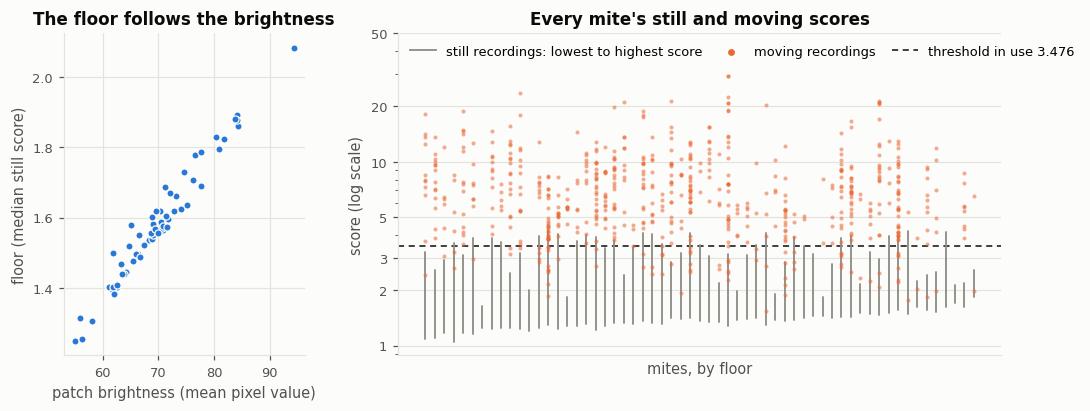

In [5]:
order = np.argsort(floor)
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [2, 5], "wspace": 0.22})

ax.scatter(brightness, floor, s=22, color=BLUE, edgecolor="#fcfcfb", linewidth=0.8)
ax.set(xlabel="patch brightness (mean pixel value)", ylabel="floor (median still score)",
       title="The floor follows the brightness")

for x, m in enumerate(order):
    ax2.plot([x, x], [np.nanmin(still_scores[m]), np.nanmax(still_scores[m])], color=GREY, linewidth=1.2,
             solid_capstyle="round", zorder=2)
    ax2.scatter(np.full(moving[m].sum(), x), S[m][moving[m]], s=7, color=ORANGE, alpha=0.55, linewidth=0, zorder=3)
ax2.plot([], [], color=GREY, linewidth=1.2, label="still recordings: lowest to highest score")
ax2.scatter([], [], s=12, color=ORANGE, label="moving recordings")
ax2.axhline(THRESHOLD, color=INK, linewidth=1, linestyle=(0, (4, 3)), zorder=1, label=f"threshold in use {THRESHOLD:g}")
ax2.set_yscale("log")
ax2.set_yticks([1, 2, 3, 5, 10, 20, 50], labels=["1", "2", "3", "5", "10", "20", "50"])
ax2.set(xlabel="mites, by floor", ylabel="score (log scale)", xticks=[],
        title="Every mite's still and moving scores")
ax2.grid(axis="x", visible=False)
ax2.legend(loc="upper left", ncols=3, columnspacing=1.2)
plt.show()

## Do the normalisations help?

`classes/score_normalizer.py` can scale each score to the run's typical brightness and move each mite's floor to the common one. For each combination: how well the scores tell moving from still recording by recording (AUC, and the threshold `calibration.best_threshold()` suggests, by sensitivity + specificity), and the mean death error at that threshold and at the threshold that makes it smallest.

In [6]:
def describe_scores(scores, name):
    this = run.with_scores(scores)
    by_recording = calibration.best_threshold(scores[labelled], moving[labelled])
    by_death, error = death_calibration.best_threshold([this])
    return {"normalised by": name, "AUC": calibration.auc(scores[labelled], moving[labelled]),
            "threshold by recording": by_recording,
            "death error there": death_calibration.death_mae([this], [by_recording])[0],
            "threshold by death": by_death, "death error": error}

normalisations = {"nothing": (False, False), "brightness": (True, False), "floor": (False, True),
                  "brightness + floor": (True, True)}
display(pd.DataFrame([describe_scores(normalised(S, B, *on), name) for name, on in normalisations.items()])
        .style.format({"AUC": "{:.4f}", "threshold by recording": "{:.3g}", "threshold by death": "{:.3g}",
                       "death error there": "{:.1f}", "death error": "{:.1f}"}).hide(axis="index"))

normalised by,AUC,threshold by recording,death error there,threshold by death,death error
nothing,0.9974,2.26,12.7,4.18,3.5
brightness,0.9956,1.98,15.4,4.31,3.9
floor,0.9947,1.93,14.2,4.04,3.4
brightness + floor,0.9956,1.94,15.8,4.25,3.6


## The threshold by the death-time error

Each threshold is judged by the mean distance, in recordings, between the death by the detector and the death by the labels. A low threshold has false calls after the death (deaths too late); a high one misses the last, weak movements (deaths too early).

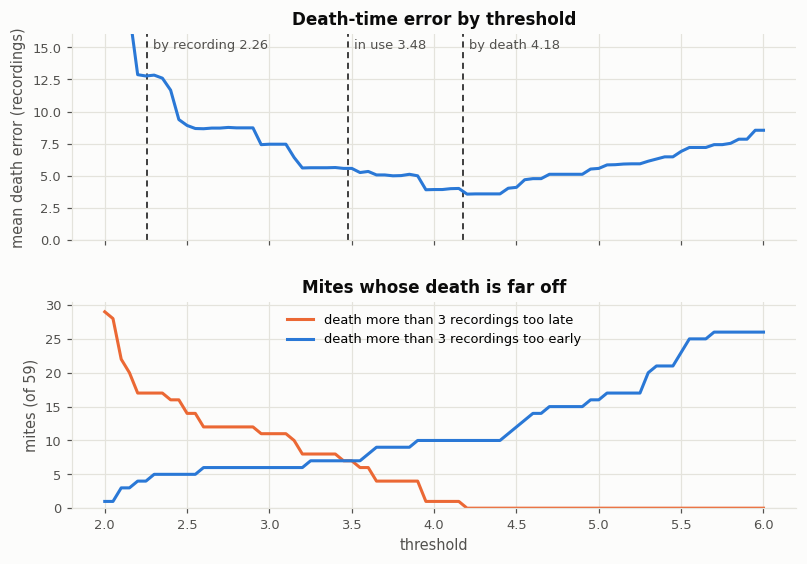

In [7]:
grid = np.round(np.arange(2.0, 6.001, 0.05), 2)
calls = S[None] >= grid[:, None, None]
errors = run.death_errors(calls)                 # (thresholds, mites), signed
mae = np.abs(errors).mean(axis=1)
by_recording = calibration.best_threshold(S[labelled], moving[labelled])
by_death, _ = death_calibration.best_threshold([run])

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(8.5, 5.6), sharex=True, gridspec_kw={"hspace": 0.3})
ax.plot(grid, mae, color=BLUE)
ceiling = 1.25 * mae[grid >= by_recording].max()  # the steep rise below is cut off
for value, label in ((by_recording, "by recording"), (THRESHOLD, "in use"), (by_death, "by death")):
    ax.axvline(value, color=INK, linewidth=1, linestyle=(0, (4, 3)), zorder=1)
    ax.annotate(f"{label} {value:.3g}", (value, ceiling), xytext=(4, -3), textcoords="offset points",
                va="top", fontsize=8.5, color=MUTED)
ax.set(ylabel="mean death error (recordings)", title="Death-time error by threshold", ylim=(0, ceiling))
ax2.plot(grid, (errors > 3).sum(axis=1), color=ORANGE, label="death more than 3 recordings too late")
ax2.plot(grid, (errors < -3).sum(axis=1), color=BLUE, label="death more than 3 recordings too early")
ax2.set(xlabel="threshold", ylabel=f"mites (of {n_mites})", title="Mites whose death is far off", ylim=(0, None))
ax2.legend(loc="upper center")
plt.show()

The table gives the same at a few thresholds, with the share of still recordings called moving. `P(false call)` is the chance of at least one false call in 250 still recordings, about what a mite of this run has after its death, taking the false calls as independent of each other.

In [8]:
def at_threshold(threshold, name=""):
    called = S >= threshold
    error = run.death_errors(called)
    false_rate = (called & still).sum() / still.sum()
    return {"threshold": threshold, "which": name,
            "sensitivity": (called & moving).sum() / moving.sum(), "false calls": false_rate,
            "P(false call)": 1 - (1 - false_rate) ** 250,
            "exact deaths": int((error == 0).sum()), "late by >3": int((error > 3).sum()),
            "early by >3": int((error < -3).sum()), "death error": np.abs(error).mean()}

chosen = sorted({by_recording: "by recording", 3.0: "", THRESHOLD: "in use", 3.75: "", 4.0: "", 4.25: "", 4.5: "", 5.0: "",
                 by_death: "by death"}.items())
display(pd.DataFrame([at_threshold(value, name) for value, name in chosen]).style.format({
    "threshold": "{:.3g}", "sensitivity": "{:.3f}", "false calls": "{:.3%}", "P(false call)": "{:.0%}",
    "death error": "{:.1f}"}).hide(axis="index"))

threshold,which,sensitivity,false calls,P(false call),exact deaths,late by >3,early by >3,death error
2.26,by recording,0.980,1.170%,95%,26,17,4,12.7
3,,0.919,0.354%,59%,33,11,6,7.5
3.48,in use,0.877,0.210%,41%,37,7,7,5.6
3.75,,0.851,0.138%,29%,40,4,9,5.0
4,,0.803,0.054%,13%,43,1,10,3.9
4.18,by death,0.782,0.012%,3%,44,0,10,3.5
4.25,,0.776,0.000%,0%,44,0,10,3.6
4.5,,0.736,0.000%,0%,43,0,12,4.1
5,,0.680,0.000%,0%,38,0,16,5.6


### Does it hold on mites it was not chosen on?

The mites are split in half 500 times; the threshold with the smallest death error on one half is judged on the other, next to the threshold in use on that same half.

threshold picked on half the mites: median 3.95, 8 in 10 between 3.75 and 4.20
death error on the other half: 4.5 picked, 5.6 at 3.476 in use; the picked one is better in 85% of the splits


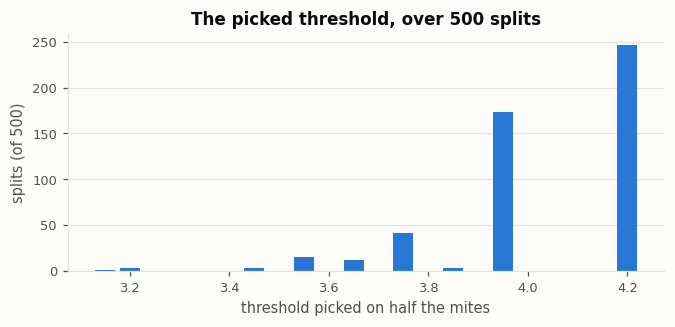

In [9]:
rng = np.random.default_rng(1)
absolute = np.abs(errors)
in_use_error = np.abs(run.death_errors(S >= THRESHOLD))
picked, held_out, held_out_in_use = [], [], []
for _ in range(500):
    shuffled = rng.permutation(n_mites)
    train, test = shuffled[:n_mites // 2], shuffled[n_mites // 2:]
    best = absolute[:, train].mean(axis=1).argmin()
    picked.append(grid[best])
    held_out.append(absolute[best, test].mean())
    held_out_in_use.append(in_use_error[test].mean())
picked, held_out, held_out_in_use = map(np.array, (picked, held_out, held_out_in_use))

print(f"threshold picked on half the mites: median {np.median(picked):.2f}, "
      f"8 in 10 between {np.percentile(picked, 10):.2f} and {np.percentile(picked, 90):.2f}")
print(f"death error on the other half: {held_out.mean():.1f} picked, {held_out_in_use.mean():.1f} at {THRESHOLD:g} "
      f"in use; the picked one is better in {100 * (held_out < held_out_in_use).mean():.0f}% of the splits")

fig, ax = plt.subplots(figsize=(7, 2.8))
values, counts = np.unique(picked, return_counts=True)
ax.bar(values, counts, width=0.04, color=BLUE)
ax.set(xlabel="threshold picked on half the mites", ylabel="splits (of 500)", title="The picked threshold, over 500 splits")
ax.grid(axis="x", visible=False)
plt.show()

### Does it depend on the length of the run?

The same run cut to its first recordings: the shorter it is, the fewer still recordings follow a death, and the less a false call costs.

In [10]:
rows = []
for length in (12, 30, 60, 120, n_recordings):
    short = LabelledRun(S[:, :length], moving[:, :length], labelled[:, :length])
    by_length = death_calibration.death_mae([short], grid)
    rows.append({"recordings": length, "best threshold": grid[by_length.argmin()], "death error at best": by_length.min(),
                 f"at {THRESHOLD:g} (in use)": death_calibration.death_mae([short], [THRESHOLD])[0],
                 "at 4.25": death_calibration.death_mae([short], [4.25])[0]})
display(pd.DataFrame(rows).style.format(precision=2).hide(axis="index"))

recordings,best threshold,death error at best,at 3.476 (in use),at 4.25
12,2.90,0.31,0.53,1.39
30,3.95,0.32,0.73,0.37
60,2.25,2.81,3.46,3.25
120,4.20,3.44,4.41,3.46
295,4.20,3.58,5.58,3.59


### Would asking for a second movement nearby help?

A false call is mostly alone, so a movement could be made to count only with others near it: *k* calls among the last *n* recordings. It does not help: the real movements near a death are alone too.

In [11]:
def confirmed(called, k, n):
    # a call counts only when it is one of k or more among the n recordings ending at it
    out = np.zeros_like(called)
    for at in range(called.shape[1]):
        out[:, at] = called[:, at] & (called[:, max(0, at - n + 1):at + 1].sum(axis=1) >= k)
    return out

rows = []
for threshold in (by_recording, THRESHOLD):
    called = (S >= threshold) & labelled
    for name, these in [("every call", called)] + [(f"{k} of the last {n}", confirmed(called, k, n))
                                                   for k, n in ((2, 3), (2, 6), (2, 12), (3, 12))]:
        error = run.death_errors(these)
        rows.append({"threshold": threshold, "a movement counts with": name, "exact deaths": int((error == 0).sum()),
                     "late by >3": int((error > 3).sum()), "early by >3": int((error < -3).sum()),
                     "death error": np.abs(error).mean()})
display(pd.DataFrame(rows).style.format({"threshold": "{:.3g}", "death error": "{:.1f}"}).hide(axis="index"))

threshold,a movement counts with,exact deaths,late by >3,early by >3,death error
2.26,every call,26,17,4,12.7
2.26,2 of the last 3,18,4,24,17.4
2.26,2 of the last 6,26,6,16,11.2
2.26,2 of the last 12,26,10,12,11.5
2.26,3 of the last 12,26,6,16,12.9
3.48,every call,37,7,7,5.6
3.48,2 of the last 3,18,1,32,19.3
3.48,2 of the last 6,28,1,23,11.9
3.48,2 of the last 12,31,3,17,8.4
3.48,3 of the last 12,27,2,22,13.2


## A band to check by eye

With a band around the threshold, a score at or above the band is moving, one below it is still, and one inside it is checked by eye. Here **the labels stand in for the eye**, so this is the best a check can do. Only the checks that can move a death are counted: those after the mite's last score above the band, from the last one back to the first that shows the mite moving.

In [12]:
def band_row(low, high):
    in_band = (S >= low) & (S < high) & labelled
    error = run.death_errors(run.reviewed(low, high))
    return {"low": low, "high": high, "recordings in the band": int(in_band.sum()),
            "share of all": in_band.sum() / labelled.sum(), "checks for the deaths": int(run.checks(low, high).sum()),
            "most for one mite": int(run.checks(low, high).max()), "exact deaths": int((error == 0).sum()),
            "death error": np.abs(error).mean()}

top = float(S[still].max()) + 0.001  # no still recording scores this high
tried = [(THRESHOLD, THRESHOLD), (by_death, by_death), (3.0, top), (2.75, top), (2.5, top), (2.25, top), (2.0, top),
         (2.5, 4.0), (1.8, top)]
display(pd.DataFrame([band_row(low, high) for low, high in tried]).style.format({
    "low": "{:.3g}", "high": "{:.3g}", "share of all": "{:.1%}", "death error": "{:.2f}"}).hide(axis="index"))
print(f"moving recordings below 2.5: {(moving & (S < 2.5)).sum()}, among them the last movement of "
      f"{sum(1 for m in range(n_mites) if truth_death[m] and S[m, np.flatnonzero(moving[m])[-1]] < 2.5)} mites: "
      "no band reaches those")

low,high,recordings in the band,share of all,checks for the deaths,most for one mite,exact deaths,death error
3.48,3.48,0,0.0%,0,0,37,5.58
4.18,4.18,0,0.0%,0,0,44,3.49
3,4.24,151,0.9%,32,2,50,3.14
2.75,4.24,188,1.1%,37,3,51,2.98
2.5,4.24,238,1.4%,43,4,52,2.92
2.25,4.24,334,1.9%,90,33,52,2.90
2,4.24,815,4.7%,523,234,55,2.20
2.5,4,212,1.2%,39,2,51,3.36
1.8,4.24,2648,15.3%,2193,251,57,0.83


moving recordings below 2.5: 23, among them the last movement of 7 mites: no band reaches those


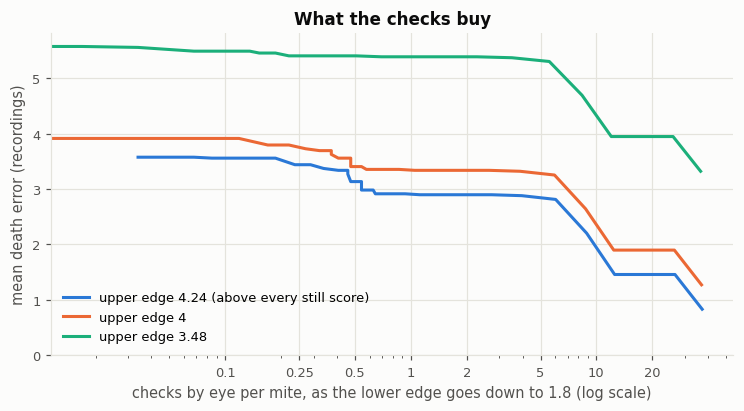

In [13]:
lows = np.round(np.arange(1.8, by_death + 0.001, 0.05), 2)
fig, ax = plt.subplots(figsize=(8, 3.8))
for high, color in ((top, BLUE), (4.0, ORANGE), (THRESHOLD, AQUA)):
    outcomes = [death_calibration.band_outcome([run], low, high) for low in lows[lows <= high]]
    ax.plot([o["checks_per_mite"] for o in outcomes], [o["mae"] for o in outcomes], color=color,
            label=f"upper edge {high:.3g}" + (" (above every still score)" if high == top else ""))
ax.set_xscale("log")
ax.set_xticks([0.1, 0.25, 0.5, 1, 2, 5, 10, 20], labels=["0.1", "0.25", "0.5", "1", "2", "5", "10", "20"])
ax.set(xlabel="checks by eye per mite, as the lower edge goes down to 1.8 (log scale)",
       ylabel="mean death error (recordings)", title="What the checks buy", ylim=(0, None))
ax.legend()
plt.show()

# Part 2: every dataset, train and test mites

The mites of every dataset are split in two, dataset by dataset. The **train** mites choose everything; the **test** mites only judge it. `scripts/optuna_death_time.py` runs one Optuna search per metric: in each trial every mite is scored with the trial's parameters, the scores go through each of the four normalisations, and for each the threshold with the smallest mean death error on the train mites is taken. The trial's value is the smallest of the four.

One split is partly luck (a few mites of the long run carry most of the error), so the best of each metric is also judged on other splits: the mites are split again, the threshold chosen on each train side and judged on its test side. The parameters stay as searched, so they were chosen with some of those test mites: read "other splits" as how much the split matters, not as the error on new mites.

In [14]:
masks = split_mites(datasets, TEST_SHARE, SEED)
display(pd.DataFrame([{"dataset": d["name"], "train mites": int(mask.sum()), "test mites": int((~mask).sum())}
                      for d, mask in zip(datasets, masks)]))

,dataset,train mites,test mites
0,ground_truth_60min,16,16
1,ground_truth_90min,14,14
2,sample_data,15,14
3,test_run_2026-09-08_Mathis_last_dsRNA,29,30


In [15]:
def load(metric):
    try:
        study = optuna.load_study(study_name=f"{STUDY}/{metric}", storage=STORAGE)
    except KeyError:
        return None
    return study if any(t.state == optuna.trial.TrialState.COMPLETE for t in study.trials) else None

studies = {metric: study for metric in Analyzer.metric_names() if (study := load(metric))}
if not studies:
    raise SystemExit(f"No study called {STUDY}: run scripts/optuna_death_time.py --study {STUDY} first.")

# Scoring optical_flow over every recording takes a moment.
results = {"in use": in_use(pool, datasets, masks, RESPLITS, TEST_SHARE, SEED)}
best_scored = {}
for metric, study in studies.items():
    attrs = dict(study.best_trial.user_attrs)
    best_scored[metric] = score_all(pool, datasets, metric, attrs["params"])
    results[metric] = {"metric": metric, "trials": len(study.trials), **attrs,
                       **resplit(datasets, best_scored[metric], attrs, RESPLITS, TEST_SHARE, SEED)}

## Results per metric

Mean death error in recordings, best on the train mites first. The first row of the table is the setup in `config.yaml` at its own threshold.

In [16]:
def normalised_by(row):
    return " + ".join(name for name, on in (("brightness", row["normalize_brightness"]),
                                            ("floor", row["normalize_floor"])) if on) or "nothing"

ranked = ["in use"] + sorted(studies, key=lambda metric: results[metric]["train_mae"])
summary = pd.DataFrame([{
    "setup": name if name != "in use" else f"in use: {results[name]['metric']}",
    "trials": results[name]["trials"], "train": results[name]["train_mae"], "test": results[name]["test_mae"],
    "other splits": results[name]["resplit_test_mae"], "+-": results[name]["resplit_test_sd"],
    "threshold": results[name]["threshold"], "normalised by": normalised_by(results[name]),
    "parameters": results[name]["params"],
} for name in ranked])
with pd.option_context("display.max_colwidth", None):
    display(summary.style.format({"train": "{:.2f}", "test": "{:.2f}", "other splits": "{:.2f}", "+-": "{:.2f}",
                                  "threshold": "{:.4g}"}).hide(axis="index"))

setup,trials,train,test,other splits,+-,threshold,normalised by,parameters
in use: topN_variability,0,1.35,3.15,2.28,0.65,3.476,nothing,{'n': 759}
topN_temporal_range,60,1.22,2.65,2.34,0.90,18.85,nothing,{'n': 21}
topN_vector_temporal_range,60,1.22,2.62,2.13,0.72,107,nothing,{'n': 6}
topN_variability,60,1.26,2.80,2.10,0.74,3.655,brightness,{'n': 512}
vector_variance,1,1.31,3.09,1.76,0.61,303.3,nothing,{}
variability,1,1.34,2.58,2.01,0.74,3.671,brightness,{}
max_diff,1,1.38,4.31,3.33,0.66,19.58,nothing,{}
optical_flow,300,1.49,3.99,3.90,1.63,0.1019,brightness,"{'window': 17, 'n': 38, 'step': 16, 'winsize': 5, 'levels': 3, 'iterations': 6, 'poly_n': 7, 'poly_sigma': 1.5, 'pad': 4}"
vector_diff,1,1.69,2.55,2.47,0.84,119.3,nothing,{}
mean_diff,1,3.27,5.59,5.19,1.24,1.755,brightness + floor,{}


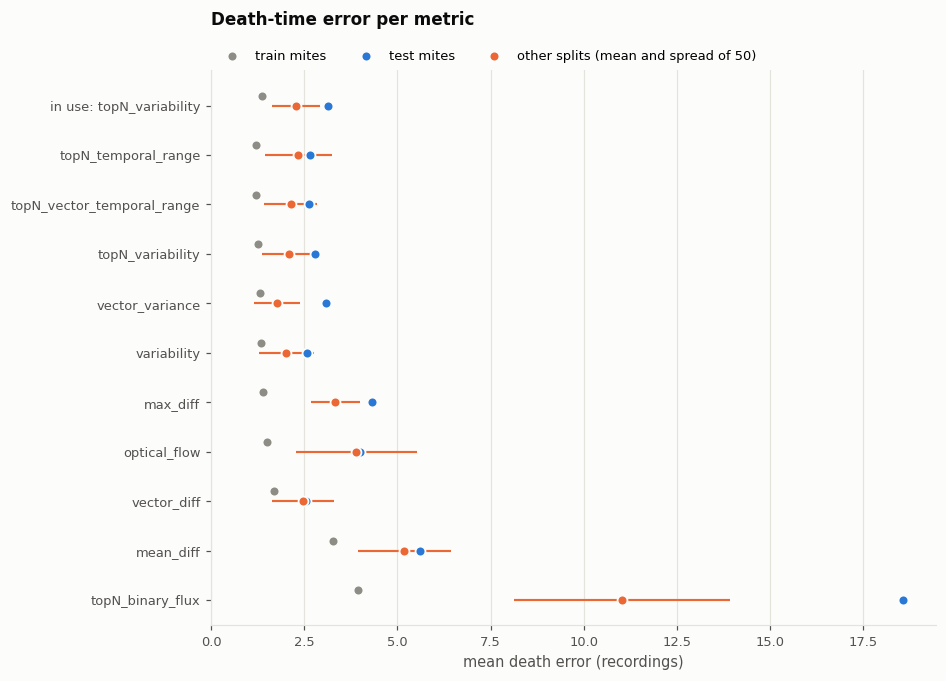

In [17]:
shown = summary[::-1].reset_index(drop=True)  # best at the top, in use above it
y = np.arange(len(shown))
fig, ax = plt.subplots(figsize=(8.5, 0.45 * len(shown) + 1.6))
ax.errorbar(shown["other splits"], y, xerr=shown["+-"], fmt="none", ecolor=ORANGE, elinewidth=1.4, capsize=0, zorder=2)
for column, color, label, dy in (("train", GREY, "train mites", 0.2), ("test", BLUE, "test mites", 0),
                                 ("other splits", ORANGE, f"other splits (mean and spread of {RESPLITS})", -0.2)):
    offset = y if column == "other splits" else y + dy
    ax.scatter(shown[column], offset, s=42, color=color, edgecolor="#fcfcfb", linewidth=1.2, label=label, zorder=3)
ax.set_yticks(y, shown["setup"])
ax.set(xlabel="mean death error (recordings)", xlim=(0, None))
ax.grid(axis="y", visible=False)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.0), ncols=3, borderaxespad=0.2)
ax.set_title("Death-time error per metric", pad=30, loc="left")
plt.show()

### The test mites, dataset by dataset

The long run carries the pooled error: in the three short datasets (6 recordings each) a death can be at most 6 recordings off.

In [18]:
names = [d["name"] for d in datasets]
display(pd.DataFrame([{"setup": setup, **{name: results[key][f"test_mae {name}"] for name in names}}
                      for setup, key in zip(summary["setup"], ranked)]).style.format(precision=2).hide(axis="index"))

setup,ground_truth_60min,ground_truth_90min,sample_data,test_run_2026-09-08_Mathis_last_dsRNA
in use: topN_variability,0.00,0.07,0.21,7.63
topN_temporal_range,0.00,0.21,0.21,6.33
topN_vector_temporal_range,0.12,0.29,0.21,6.17
topN_variability,0.00,0.07,0.21,6.77
vector_variance,0.00,0.00,0.21,7.53
variability,0.00,0.07,0.21,6.23
max_diff,0.00,0.07,0.21,10.50
optical_flow,0.00,0.14,0.21,9.67
vector_diff,0.00,0.36,0.64,5.83
mean_diff,0.19,0.86,0.29,13.17


## The band, chosen on the train mites

For each number of checks allowed per mite, `death_calibration.best_band()` takes the band around the threshold with the smallest death error on the train mites. It is judged on the test mites, their labels standing in for the eye. Shown for the setup in use and for the best metric of the search.

In [19]:
def band_table(attrs, scored):
    table = pd.DataFrame(bands(datasets, scored, masks, attrs, CHECKS))
    return table.rename(columns={"checks_allowed": "checks allowed", "test_mae": "test error",
                                 "test_checks_per_mite": "test checks per mite", "test_exact": "test exact deaths",
                                 "train_mae": "train error"})[
        ["checks allowed", "low", "high", "train error", "test error", "test checks per mite", "test exact deaths"]]

band_format = {"low": "{:.4g}", "high": "{:.4g}", "train error": "{:.2f}", "test error": "{:.2f}",
               "test checks per mite": "{:.2f}", "test exact deaths": "{:.0%}", "checks allowed": "{:g}"}
best_metric = ranked[1]
for name, scored in (("in use", in_use_scored), (best_metric, best_scored[best_metric])):
    attrs = results[name]
    print(f"{name}: {attrs['metric']} {attrs['params']}, threshold {attrs['threshold']:.4g}, "
          f"normalised by {normalised_by(attrs)}; without a band: {attrs['train_mae']:.2f} train, {attrs['test_mae']:.2f} test")
    display(band_table(attrs, scored).style.format(band_format).hide(axis="index"))

in use: topN_variability {'n': 759}, threshold 3.476, normalised by nothing; without a band: 1.35 train, 3.15 test


checks allowed,low,high,train error,test error,test checks per mite,test exact deaths
0.25,2.688,3.942,1.07,1.62,0.30,92%
0.5,2.688,3.942,1.07,1.62,0.30,92%
1,2.688,3.942,1.07,1.62,0.30,92%
2,2.688,3.942,1.07,1.62,0.30,92%


topN_temporal_range: topN_temporal_range {'n': 21}, threshold 18.85, normalised by nothing; without a band: 1.22 train, 2.65 test


checks allowed,low,high,train error,test error,test checks per mite,test exact deaths
0.25,13.74,18.85,1.12,2.53,0.31,88%
0.5,13.74,20.62,1.07,2.16,0.46,91%
1,10.21,20.62,0.58,2.09,1.26,93%
2,10.21,20.62,0.58,2.09,1.26,93%


In [20]:
pool.shutdown()